# Cross-Sectional Signal Analysis

Do simple price and volume characteristics predict the cross-section of next-month US stock returns, and does combining them help?

Setup: monthly panel of current S&P 1500 members from 2005 to 2026 (daily data from Yahoo Finance), nine candidate signals built only from past prices and volume, rank IC tests at 1, 3 and 6 month horizons, then Ridge / Lasso / Elastic Net fitted on a chronological train / validation / test split and compared against single signals, an equal-weight combination and a naive persistence baseline. A beta-neutral decile long-short portfolio connects the statistics to returns.

The numbers quoted in the text correspond to data downloaded on 2026-09-18. Rerunning later will refresh the download and shift the figures slightly.

## 1. Setup

In [1]:
import io, logging, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso, ElasticNet

try:
    import yfinance as yf
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'yfinance'], check=True)
    import yfinance as yf

warnings.filterwarnings('ignore')
logging.getLogger('yfinance').setLevel(logging.CRITICAL)   # a couple of tickers 404 on yahoo
pd.set_option('display.width', 140)
plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9})

IN_COLAB = 'google.colab' in sys.modules
DATA_DIR = Path('data')          # local cache next to the notebook (or /content/data on Colab)
DATA_DIR.mkdir(exist_ok=True)

START = '2004-01-01'             # one year of warm-up before the first usable month
HORIZONS = [1, 3, 6]
TRAIN_END = pd.Timestamp('2015-12-31')
VAL_END = pd.Timestamp('2019-12-31')
MIN_PRICE, MIN_DOLLAR_VOL, MIN_OBS = 5.0, 1e6, 200
print('python', sys.version.split()[0], '| pandas', pd.__version__, '| colab:', IN_COLAB)

python 3.14.2 | pandas 3.0.6 | colab: False


## 2. Data acquisition

Source: Yahoo Finance via `yfinance` (free, no key). Ticker lists are the current S&P 500, S&P MidCap 400 and S&P SmallCap 600 constituents from Wikipedia. Using the 1500 rather than only the 500 keeps names that were demoted after large drawdowns inside the sample, which matters for survivorship (section 4). Downloads are cached under `data/` so reruns are fast.

In [2]:
def wiki_constituents():
    pages = {'sp500': 'List_of_S%26P_500_companies', 'sp400': 'List_of_S%26P_400_companies',
             'sp600': 'List_of_S%26P_600_companies'}
    frames = []
    for name, page in pages.items():
        html = requests.get(f'https://en.wikipedia.org/wiki/{page}',
                            headers={'User-Agent': 'Mozilla/5.0'}, timeout=30).text
        t = pd.read_html(io.StringIO(html))[0][['Symbol', 'Security', 'GICS Sector']]
        t['index'] = name
        frames.append(t)
    cons = pd.concat(frames, ignore_index=True)
    cons['ticker'] = cons['Symbol'].str.replace('.', '-', regex=False)   # yahoo uses BRK-B not BRK.B
    return cons.drop_duplicates('ticker').reset_index(drop=True)

cons_file = DATA_DIR / 'constituents.csv'
if cons_file.exists():
    cons = pd.read_csv(cons_file)
else:
    cons = wiki_constituents()
    cons.to_csv(cons_file, index=False)
tickers = sorted(cons['ticker'])
print(len(tickers), 'tickers', cons['index'].value_counts().to_dict())

price_file = DATA_DIR / 'prices.parquet'
if price_file.exists():
    raw = pd.read_parquet(price_file)
else:
    t0 = time.time()
    raw = yf.download(tickers + ['SPY'], start=START, auto_adjust=False, progress=False,
                      threads=True, group_by='column')[['Adj Close', 'Close', 'Volume']]
    raw.to_parquet(price_file)
    print(f'downloaded in {time.time() - t0:.0f}s')
raw.index = pd.to_datetime(raw.index)
print('daily rows:', len(raw), '| first:', raw.index[0].date(), '| last:', raw.index[-1].date())

1506 tickers {'sp600': 603, 'sp500': 503, 'sp400': 400}


daily rows: 5713 | first: 2004-01-02 | last: 2026-09-17


## 3. Data cleaning

`Adj Close` is split and dividend adjusted, `Close` is split adjusted only, so the ratio of the two should only move on ex-dividend dates. Two kinds of vendor errors show up in the raw data:

- the adjustment ratio jumps by a large factor in one day (a mis-recorded dividend, e.g. TDS in May 2005)
- the unadjusted price itself jumps by several hundred percent (a re-listing after bankruptcy spliced onto the old ticker, e.g. CHRD in Nov 2020, or mis-recorded reverse splits in illiquid names)

Flagged days get a zero return and a clean total-return index is rebuilt from daily returns. All other returns are left as they are, including genuine extreme moves.

In [3]:
adj, close, vol = raw['Adj Close'].copy(), raw['Close'].copy(), raw['Volume'].copy()
have = adj.notna().sum() > 0                      # drop tickers yahoo returned nothing for
adj, close, vol = adj.loc[:, have], close.loc[:, have], vol.loc[:, have]
mkt = adj.pop('SPY')
close, vol = close.drop(columns='SPY'), vol.drop(columns='SPY')
adj, close, vol = adj.where(adj > 0), close.where(close > 0), vol.where(vol > 0)

la = np.log(adj.ffill()).diff().where(adj.notna())
lc = np.log(close.ffill()).diff().where(close.notna())
bad_adj = (la - lc).abs() > np.log(1.5)             # implied one-day dividend adjustment above 50%
bad_px = (lc > np.log(2.5)) | (lc < np.log(0.2))    # unadjusted move above +150% or below -80%
bad = bad_adj | bad_px
print(f'flagged days: {int(bad.sum().sum())} (adjustment: {int(bad_adj.sum().sum())}, price: {int(bad_px.sum().sum())})',
      f'across {int(bad.any().sum())} tickers')

la = la.mask(bad, 0.0)
tr = np.exp(la.fillna(0).cumsum()).where(adj.notna())   # clean total-return index, arbitrary level
dret = np.expm1(la)
mret = np.expm1(np.log(mkt).diff())

dates = adj.index
month_end = pd.Series(dates, index=dates).groupby(dates.to_period('M')).last()
month_end = month_end[month_end.index < dates[-1].to_period('M')]   # drop the partial current month
me = pd.DatetimeIndex(month_end.values)
print('tickers:', adj.shape[1], '| month ends:', len(me), me[0].date(), 'to', me[-1].date())
print('daily returns:', dret.stack().describe()[['count', 'mean', 'std', 'min', 'max']].round(4).to_dict())

flagged days: 54 (adjustment: 22, price: 33) across 38 tickers


tickers: 1505 | month ends: 272 2004-01-30 to 2026-08-31


daily returns: {'count': 7023030.0, 'mean': 0.0007, 'std': 0.0266, 'min': -0.7872, 'max': 1.4624}


## 4. Universe construction

A stock is in the universe at month-end t if it has a price above 5 dollars, a 63-day median dollar volume of at least 1 million, at least 200 valid daily returns in the past year, and 12 months of price history. The screen only uses data up to t. One caveat: Yahoo's `Close` is split-adjusted as of the download date, so the price filter sees today's split-adjusted price rather than the price quoted at the time (dollar volume is unaffected because volume is adjusted the other way).

The ticker list is not point-in-time and this is the main limitation of the dataset. Everything here is a current index member, so companies that were acquired, went bankrupt or were dropped from all three indices before 2026 are missing. Taking the 1500 rather than the 500 reduces one channel of the bias (a stock demoted from the 500 to the 600 after a collapse is still observed), but the delisting channel remains. The expected consequence: stocks that fell a lot and survived are over-represented, which should favour contrarian signals (short-term reversal, high volatility) and work against momentum. The size of the effect is not measured here, so the results below need to be read with that in mind.

In [4]:
nobs = dret.notna().rolling(252).sum()
dvol = (close * vol).rolling(63, min_periods=40).median()
P = tr.reindex(me)
elig = ((close.reindex(me) > MIN_PRICE) & (dvol.reindex(me) >= MIN_DOLLAR_VOL)
        & (nobs.reindex(me) >= MIN_OBS) & P.notna() & P.shift(12).notna())
usize = elig.sum(axis=1)
print('universe size by year (average of month ends):')
print(usize.groupby(me.year).mean().round(0).astype(int).to_frame('n').T.to_string())

universe size by year (average of month ends):
   2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
n     0   773   837   893   891   860   918   958   974  1031  1093  1142  1184  1229  1271  1301  1326  1377  1417  1440  1463  1479  1487


## 5. Feature construction

All signals use data up to and including month-end t. Forward returns run from t to t+h month-ends. Definitions:

| signal | definition |
|---|---|
| `rev_1m` | minus the return over the last month (short-term reversal; 1-month momentum is the same variable with the opposite sign, so it is not included separately) |
| `mom_3m`, `mom_6m`, `mom_12m` | return from t-3, t-6, t-12 to t-1, skipping the most recent month |
| `accel` | return over t-3 to t minus return over t-6 to t-3 |
| `rvol_3m` | annualised standard deviation of daily returns over the last 63 days |
| `vol_surp` | log of average volume over the last 21 days minus log of average volume over the prior 126 days |
| `dist_ma200` | price relative to its 200-day moving average, minus 1 |
| `bam_12m` | `mom_12m` minus beta times the market 12-1 return, with beta from 252 daily returns against SPY |

Market beta is also kept per stock-month. Forward returns are stored both raw and beta-adjusted (stock return minus ex-ante beta times SPY return); the adjusted version is the main target, because with raw returns part of the month-to-month variation in IC comes from whether high-beta names happened to beat low-beta names, which is not what the signals are meant to predict.

In [5]:
def r(a, b):
    return P.shift(b) / P.shift(a) - 1        # return from month t-a to t-b

rv = dret.rolling(63, min_periods=50).std() * np.sqrt(252)
vsurp = np.log(vol.rolling(21, min_periods=15).mean()) - np.log(vol.shift(21).rolling(126, min_periods=90).mean())
ma200 = tr.rolling(200, min_periods=180).mean()
beta = dret.rolling(252, min_periods=200).cov(mret).div(mret.rolling(252, min_periods=200).var(), axis=0)
beta_m = beta.reindex(me).clip(0.0, 3.0)
Pm = mkt.reindex(me)

feat = {
    'rev_1m': -r(1, 0),
    'mom_3m': r(3, 1),
    'mom_6m': r(6, 1),
    'mom_12m': r(12, 1),
    'accel': r(3, 0) - r(6, 3),
    'rvol_3m': rv.reindex(me),
    'vol_surp': vsurp.reindex(me),
    'dist_ma200': (tr / ma200 - 1).reindex(me),
}
feat['bam_12m'] = feat['mom_12m'] - beta_m.mul(Pm.shift(1) / Pm.shift(12) - 1, axis=0)
FEATS = list(feat)

fwd = {h: P.shift(-h) / P - 1 for h in HORIZONS}
mkt_fwd = {h: Pm.shift(-h) / Pm - 1 for h in HORIZONS}
cols = dict(feat)
cols.update({f'fwd_{h}': fwd[h] for h in HORIZONS})
cols.update({f'fwdadj_{h}': fwd[h] - beta_m.mul(mkt_fwd[h], axis=0) for h in HORIZONS})
cols['beta'] = beta_m

panel = pd.concat({k: v.where(elig).stack() for k, v in cols.items()}, axis=1)
panel.index.names = ['date', 'ticker']
panel = panel.dropna(subset=FEATS + ['beta'])
pdates = panel.index.get_level_values('date')
print('stock-months:', len(panel), '| months:', pdates.nunique(), '| tickers:', panel.index.get_level_values('ticker').nunique())
print('first month with data:', pdates.min().date())
panel[FEATS].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)

stock-months: 298167 | months: 260 | tickers: 1495
first month with data: 2005-01-31


,mean,std,min,50%,max
rev_1m,-0.014,0.110,-16.251,-0.011,0.843
mom_3m,0.028,0.158,-0.910,0.022,18.626
mom_6m,0.072,0.289,-0.946,0.054,47.653
mom_12m,0.165,0.605,-0.990,0.110,105.711
accel,-0.001,0.282,-30.507,-0.007,28.430
rvol_3m,0.346,0.196,0.027,0.296,5.061
vol_surp,-0.012,0.316,-5.037,-0.030,3.688
dist_ma200,0.048,0.185,-0.967,0.047,20.554
bam_12m,0.034,0.570,-1.828,-0.004,104.552


## 6. Cross-sectional normalization

Each signal is winsorised at the 1st and 99th percentile within each month and then z-scored within the month. The model target is the beta-adjusted 1-month forward return, winsorised and standardised the same way. Standardising the target matters for the pooled regressions later: without it, months with very wide return dispersion (2008-2009, March 2020) dominate the fit.

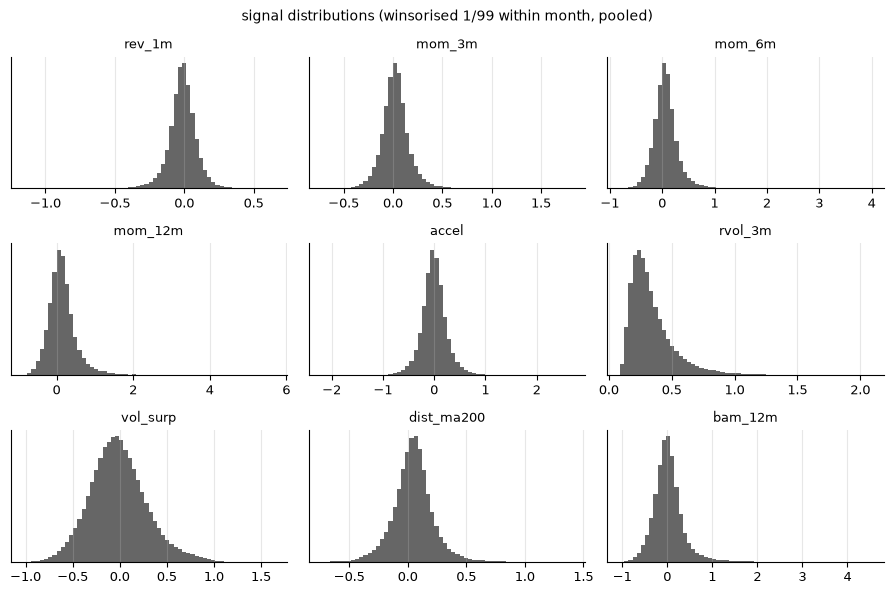

In [6]:
def winsorize_cs(df, cols, lo=0.01, hi=0.99):
    g = df.groupby(level='date')[cols]
    return df[cols].clip(g.transform('quantile', lo), g.transform('quantile', hi))

def standardize_cs(df):
    g = df.groupby(level='date')
    return (df - g.transform('mean')) / g.transform('std')

Z = standardize_cs(winsorize_cs(panel, FEATS))
Y = standardize_cs(winsorize_cs(panel, [f'fwdadj_{h}' for h in HORIZONS]))
Y.columns = [f'y_{h}' for h in HORIZONS]

fig, axes = plt.subplots(3, 3, figsize=(9, 6))
W = winsorize_cs(panel, FEATS)
for ax, f in zip(axes.ravel(), FEATS):
    ax.hist(W[f].dropna(), bins=60, color='0.4')
    ax.set_title(f, fontsize=9); ax.set_yticks([])
fig.suptitle('signal distributions (winsorised 1/99 within month, pooled)', fontsize=10)
fig.tight_layout()

## 7. Signal diagnostics

The momentum family is heavily correlated by construction. To keep the model interpretable, a candidate is dropped if its Spearman correlation with an already retained signal exceeds 0.7 (greedy, in the listed order).

retained: ['rev_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'accel', 'rvol_3m', 'vol_surp']
dropped (most correlated retained signal): {'dist_ma200': 'mom_6m', 'bam_12m': 'mom_12m'}


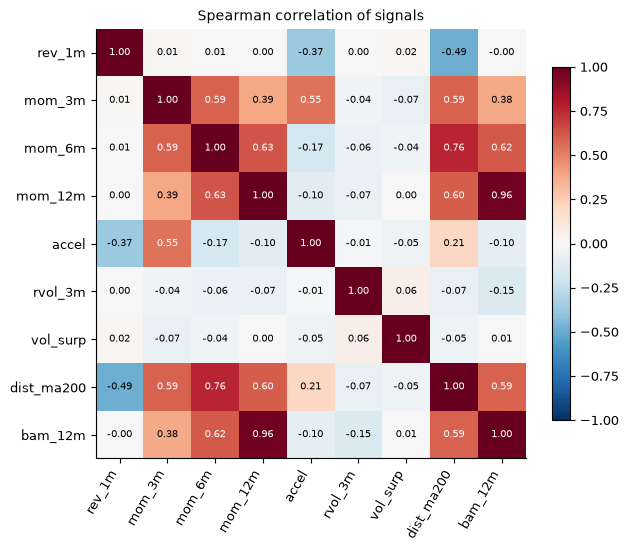

In [7]:
C = Z.corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS))); ax.set_xticklabels(FEATS, rotation=60, ha='right')
ax.set_yticks(range(len(FEATS))); ax.set_yticklabels(FEATS); ax.grid(False)
for i in range(len(FEATS)):
    for j in range(len(FEATS)):
        ax.text(j, i, f'{C.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(C.iloc[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title('Spearman correlation of signals', fontsize=10)
fig.tight_layout()

MODEL_FEATS = []
for f in FEATS:
    if all(abs(C.loc[f, k]) < 0.7 for k in MODEL_FEATS):
        MODEL_FEATS.append(f)
dropped = {f: C.loc[f, MODEL_FEATS].abs().idxmax() for f in FEATS if f not in MODEL_FEATS}
print('retained:', MODEL_FEATS)
print('dropped (most correlated retained signal):', dropped)

## 8. Predictive testing

Rank IC is the Spearman correlation between a signal and the forward return within a month. It is computed against the winsorised, standardised target from section 6; the winsorisation ties the top and bottom 1% of returns, which changes the mean IC by less than 0.0001 relative to the unwinsorised target. Reported per signal and horizon: mean IC, its standard deviation, the information ratio (mean over std, monthly), a Newey-West t-statistic on the mean with lag equal to the horizon in months (the 3 and 6 month forward returns overlap), and the share of months with positive IC. Signals are tested with their natural sign, so a negative mean IC for `rvol_3m` means low volatility stocks did better.

In [8]:
def rank_ic(df, cols, target):
    # spearman correlation of each column with target, within each month, vectorised
    d = df[[target] + cols].dropna(subset=[target])
    rk = d.groupby(level='date').rank()
    rk = rk - rk.groupby(level='date').transform('mean')
    num = rk[cols].mul(rk[target], axis=0).groupby(level='date').sum()
    den = np.sqrt((rk[cols] ** 2).groupby(level='date').sum().mul((rk[target] ** 2).groupby(level='date').sum(), axis=0))
    return num / den

def ic_summary(ic, lags=1):
    ic = ic.dropna()
    ols = sm.OLS(ic.values, np.ones(len(ic))).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return pd.Series({'mean_ic': ic.mean(), 'ic_std': ic.std(), 'icir': ic.mean() / ic.std(),
                      't_nw': ols.tvalues[0], 'hit_rate': (ic > 0).mean(), 'n_months': len(ic)})

full = pd.concat([Z, Y], axis=1)
IC = {h: rank_ic(full, FEATS, f'y_{h}') for h in HORIZONS}
ic_table = pd.concat({h: pd.DataFrame({f: ic_summary(IC[h][f], lags=h) for f in FEATS}).T for h in HORIZONS},
                     names=['h', 'signal'])
ic_table.round(3)

mean_ic  ic_std   icir   t_nw  hit_rate  n_months
h signal                                                       
1 rev_1m        0.010   0.113  0.084  1.410     0.502     259.0
  mom_3m       -0.006   0.126 -0.047 -0.739     0.463     259.0
  mom_6m       -0.008   0.144 -0.059 -0.994     0.486     259.0
  mom_12m      -0.003   0.151 -0.019 -0.311     0.517     259.0
  accel        -0.001   0.108 -0.013 -0.217     0.506     259.0
  rvol_3m      -0.028   0.164 -0.171 -2.778     0.429     259.0
  vol_surp     -0.005   0.060 -0.091 -1.564     0.471     259.0
  dist_ma200   -0.008   0.156 -0.054 -0.916     0.502     259.0
  bam_12m       0.006   0.154  0.039  0.643     0.541     259.0
3 rev_1m        0.010   0.110  0.088  1.323     0.560     257.0
  mom_3m       -0.005   0.112 -0.043 -0.594     0.506     257.0
  mom_6m       -0.014   0.129 -0.107 -1.287     0.498     257.0
  mom_12m      -0.006   0.144 -0.039 -0.428     0.510     257.0
  accel         0.005   0.104  0.044  0.592     0.498     257.0
  rvol_3m      -0.039   0.159 -0.243 -2.654     0.397     257.0
  vol_surp     -0.003   0.056 -0.046 -0.732     0.510     257.0
  dist_ma200   -0.010   0.143 -0.068 -0.784     0.525     257.0
  bam_12m       0.007   0.148  0.044  0.464     0.549     257.0
6 rev_1m        0.009   0.107  0.083  1.261     0.476     254.0
  mom_3m       -0.010   0.108 -0.092 -1.004     0.512     254.0
  mom_6m       -0.009   0.126 -0.071 -0.606     0.547     254.0
  mom_12m      -0.007   0.138 -0.051 -0.396     0.508     254.0
  accel        -0.009   0.106 -0.088 -1.201     0.476     254.0
  rvol_3m      -0.051   0.158 -0.325 -2.612     0.354     254.0
  vol_surp     -0.001   0.053 -0.025 -0.344     0.504     254.0
  dist_ma200   -0.010   0.135 -0.077 -0.622     0.543     254.0
  bam_12m       0.011   0.149  0.071  0.538     0.579     254.0

In [9]:
# raw versus beta-adjusted target at the 1-month horizon
raw_ic = rank_ic(pd.concat([Z, panel['fwd_1']], axis=1), FEATS, 'fwd_1')
pd.DataFrame({'raw return': raw_ic.mean(), 'beta-adjusted': IC[1].mean(),
              'ic_std raw': raw_ic.std(), 'ic_std adj': IC[1].std()}).round(4)

,raw return,beta-adjusted,ic_std raw,ic_std adj
rev_1m,0.0100,0.0095,0.1288,0.1130
mom_3m,-0.0034,-0.0059,0.1380,0.1262
mom_6m,-0.0067,-0.0085,0.1509,0.1440
mom_12m,0.0003,-0.0029,0.1617,0.1508
accel,-0.0020,-0.0015,0.1193,0.1079
rvol_3m,0.0047,-0.0280,0.2045,0.1644
vol_surp,-0.0081,-0.0054,0.0585,0.0595
dist_ma200,-0.0061,-0.0084,0.1663,0.1558
bam_12m,0.0012,0.0059,0.1588,0.1537


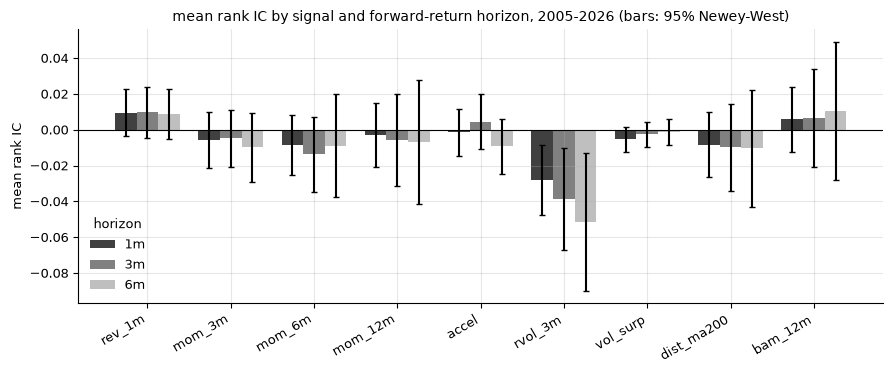

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(FEATS)); w = 0.26
for i, h in enumerate(HORIZONS):
    m = ic_table.xs(h)['mean_ic']; se = m / ic_table.xs(h)['t_nw']
    ax.bar(x + (i - 1) * w, m, w, yerr=1.96 * se.abs(), capsize=2, label=f'{h}m', color=str(0.25 + 0.25 * i))
ax.axhline(0, color='k', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(FEATS, rotation=30, ha='right')
ax.set_ylabel('mean rank IC'); ax.legend(title='horizon', frameon=False)
ax.set_title('mean rank IC by signal and forward-return horizon, 2005-2026 (bars: 95% Newey-West)', fontsize=10)
fig.tight_layout()

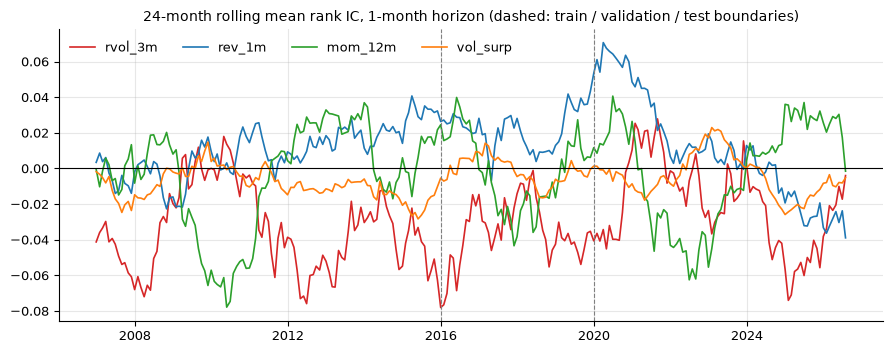

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for f, c in [('rvol_3m', 'C3'), ('rev_1m', 'C0'), ('mom_12m', 'C2'), ('vol_surp', 'C1')]:
    ax.plot(IC[1][f].rolling(24).mean(), label=f, color=c, lw=1.2)
ax.axhline(0, color='k', lw=0.8)
for d in (TRAIN_END, VAL_END):
    ax.axvline(d, color='0.5', ls='--', lw=0.8)
ax.set_title('24-month rolling mean rank IC, 1-month horizon (dashed: train / validation / test boundaries)', fontsize=10)
ax.legend(frameon=False, ncol=4); fig.tight_layout()

## 9. Model fitting

Pooled linear regressions of the standardised 1-month target on the retained z-scored signals. Ridge, Lasso and Elastic Net (l1 ratio 0.5) are fitted on the training period; the penalty is chosen by mean validation IC; the chosen model is then refitted on train plus validation and scored on the test period. No shuffling anywhere.

Rank IC only depends on the direction of the coefficient vector, not its scale, so coefficients are reported as relative weights. For Ridge the limit of very heavy shrinkage is a coefficient vector proportional to the pooled covariances between each signal and the target, i.e. a combination weighted by each signal's pooled Pearson correlation with the target.

- train: 2005-01 to 2015-12
- validation: 2016-01 to 2019-12
- test: 2020-01 to 2026-07 (last month with a known forward return)

In [12]:
y = Y['y_1']
X = Z[MODEL_FEATS].values
train = (pdates <= TRAIN_END) & y.notna().values
val = (pdates > TRAIN_END) & (pdates <= VAL_END) & y.notna().values
test = (pdates > VAL_END) & y.notna().values
print('observations  train:', train.sum(), '| val:', val.sum(), '| test:', test.sum())

def fit_predict(model, fit_mask):
    model.fit(X[fit_mask], y.values[fit_mask])
    return pd.Series(model.predict(X), index=panel.index), model

def mean_ic(pred, mask):
    d = pd.concat([pred.rename('p'), y.rename('t')], axis=1)[mask]
    return rank_ic(d, ['p'], 't')['p'].mean()

grids = {'ridge': [1e2, 1e3, 1e4, 1e5, 1e6, 1e7], 'lasso': [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3],
         'enet': [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]}
make = {'ridge': lambda a: Ridge(alpha=a), 'lasso': lambda a: Lasso(alpha=a),
        'enet': lambda a: ElasticNet(alpha=a, l1_ratio=0.5)}
val_ic, train_fit = {}, {}
for name, grid in grids.items():
    for a in grid:
        pred, m = fit_predict(make[name](a), train)
        train_fit[(name, a)] = (pred, m.coef_.copy())
        val_ic[(name, a)] = mean_ic(pred, val) if np.abs(m.coef_).sum() > 0 else np.nan
val_ic = pd.Series(val_ic).unstack(0)
print('validation mean IC by penalty (nan: all coefficients shrunk to zero)')
display(val_ic.round(4))

best_alpha = {name: val_ic[name].idxmax() for name in grids}
models, preds, preds_train_only = {}, {}, {}
for name in grids:
    preds_train_only[name] = train_fit[(name, best_alpha[name])][0]      # for the validation table
    preds[name], models[name] = fit_predict(make[name](best_alpha[name]), train | val)   # for the test table
coef = pd.concat({'train only': pd.DataFrame({n: train_fit[(n, best_alpha[n])][1] for n in grids}, index=MODEL_FEATS),
                  'train + validation': pd.DataFrame({n: m.coef_ for n, m in models.items()}, index=MODEL_FEATS)}, axis=1)
print('chosen penalties:', {k: float(v) for k, v in best_alpha.items()})
print('relative weights (coefficient divided by the sum of absolute coefficients):')
(coef / coef.abs().sum()).round(3)

observations  train: 124438 | val: 59818 | test: 112425


validation mean IC by penalty (nan: all coefficients shrunk to zero)


,enet,lasso,ridge
1.000000e-05,0.0220,0.0221,NaN
3.000000e-05,0.0221,0.0223,NaN
1.000000e-04,0.0225,0.0232,NaN
3.000000e-04,0.0237,0.0246,NaN
1.000000e-03,0.0248,0.0262,NaN
3.000000e-03,0.0264,0.0269,NaN
1.000000e+02,NaN,NaN,0.0221
1.000000e+03,NaN,NaN,0.0232
1.000000e+04,NaN,NaN,0.0256
1.000000e+05,NaN,NaN,0.0279


chosen penalties: {'ridge': 10000000.0, 'lasso': 0.003, 'enet': 0.003}
relative weights (coefficient divided by the sum of absolute coefficients):


train only               train + validation              
              ridge  lasso   enet              ridge  lasso   enet
rev_1m        0.131  0.080  0.095              0.371  0.465  0.468
mom_3m       -0.041 -0.003 -0.034              0.022  0.000  0.000
mom_6m       -0.016 -0.000 -0.068              0.005  0.000  0.000
mom_12m       0.120  0.138  0.196              0.013  0.000  0.000
accel        -0.044 -0.000  0.000             -0.120 -0.000  0.000
rvol_3m      -0.578 -0.779 -0.607             -0.415 -0.535 -0.532
vol_surp     -0.071 -0.000 -0.000             -0.054 -0.000 -0.000

## 10. Out-of-sample evaluation

Comparison set on the test period:

- `ridge`, `lasso`, `enet`: the fitted models
- `ew_combo`: equal-weight average of the retained z-scores, each signed by its training-period mean IC
- `naive_persistence`: last month's return as the forecast of next month's relative return
- single signals, each signed by its training-period mean IC so that a positive IC means the training sign carried over

In [13]:
sign = np.sign(IC[1].loc[IC[1].index <= TRAIN_END, MODEL_FEATS].mean())
preds['ew_combo'] = (Z[MODEL_FEATS] * sign).mean(axis=1)
preds['naive_persistence'] = -Z['rev_1m']
for f in MODEL_FEATS:
    preds[f] = Z[f] * sign[f]
PRED = pd.DataFrame(preds)

def evaluate(pred_frame, mask, lags=1):
    d = pd.concat([pred_frame, y.rename('t')], axis=1)[mask]
    ic = rank_ic(d, list(pred_frame.columns), 't')
    return pd.DataFrame({c: ic_summary(ic[c], lags) for c in pred_frame.columns}).T, ic

print('training-period signs used for ew_combo and single signals:', sign.astype(int).to_dict())
test_tab, test_ic = evaluate(PRED, test)
PRED_VAL = PRED.copy()
for name in grids:
    PRED_VAL[name] = preds_train_only[name]      # models fitted on the training period only
val_tab, _ = evaluate(PRED_VAL, val)
print('validation period (2016-2019), models fitted on 2005-2015 only')
display(val_tab.round(3))
print('test period (2020-2026)')
test_tab.round(3)

training-period signs used for ew_combo and single signals: {'rev_1m': 1, 'mom_3m': -1, 'mom_6m': -1, 'mom_12m': 1, 'accel': -1, 'rvol_3m': -1, 'vol_surp': -1}


validation period (2016-2019), models fitted on 2005-2015 only


,mean_ic,ic_std,icir,t_nw,hit_rate,n_months
ridge,0.029,0.148,0.198,1.441,0.583,48.0
lasso,0.027,0.158,0.170,1.270,0.521,48.0
enet,0.026,0.155,0.171,1.268,0.562,48.0
ew_combo,0.019,0.116,0.162,1.123,0.562,48.0
naive_persistence,-0.041,0.116,-0.351,-2.483,0.417,48.0
rev_1m,0.041,0.116,0.351,2.483,0.583,48.0
mom_3m,-0.006,0.138,-0.047,-0.302,0.500,48.0
mom_6m,0.003,0.152,0.023,0.171,0.583,48.0
mom_12m,-0.013,0.171,-0.078,-0.621,0.438,48.0
accel,0.010,0.122,0.084,0.543,0.521,48.0


test period (2020-2026)


,mean_ic,ic_std,icir,t_nw,hit_rate,n_months
ridge,0.003,0.147,0.019,0.175,0.481,79.0
lasso,0.005,0.153,0.032,0.292,0.494,79.0
enet,0.005,0.153,0.031,0.287,0.494,79.0
ew_combo,0.012,0.122,0.097,0.834,0.481,79.0
naive_persistence,0.007,0.117,0.063,0.668,0.570,79.0
rev_1m,-0.007,0.117,-0.063,-0.668,0.430,79.0
mom_3m,0.013,0.136,0.095,0.894,0.544,79.0
mom_6m,0.012,0.156,0.075,0.699,0.456,79.0
mom_12m,-0.007,0.152,-0.048,-0.419,0.557,79.0
accel,-0.002,0.107,-0.018,-0.173,0.506,79.0


## 11. Portfolio simulation

Monthly rebalanced decile portfolio: long the top decile of the score, short the bottom decile, equal weight within each leg. The short leg is scaled so that the portfolio has zero ex-ante beta (consistent with the beta-adjusted target), then weights are normalised to a gross notional of 2. Returns are raw stock returns. Turnover is the sum of absolute weight changes at each rebalance (ignoring intra-month drift), so a full liquidation of both legs is 4. Costs are charged at an assumed fixed rate per unit of turnover, with 10 bps as a low estimate for liquid US large caps and 25 to 50 bps as a rough allowance for small caps and market impact; the cost levels are assumptions, not estimated from data.

In [14]:
def decile_ls(score, ret, beta, q=10):
    d = pd.concat([score.rename('s'), ret.rename('r'), beta.rename('b')], axis=1).dropna()
    rk = d.groupby(level='date')['s'].rank(pct=True)
    w = pd.Series(0.0, index=d.index)
    w[rk > 1 - 1 / q] = 1.0
    w[rk <= 1 / q] = -1.0
    dts = w.index.get_level_values('date')
    n_long = w[w > 0].groupby(level='date').count().reindex(dts).values
    n_short = w[w < 0].groupby(level='date').count().reindex(dts).values
    w = w.where(w <= 0, w / n_long).where(w >= 0, w / n_short)
    b_long = (w.clip(lower=0) * d['b']).groupby(level='date').sum()
    b_short = (-w.clip(upper=0) * d['b']).groupby(level='date').sum()
    w = w.where(w >= 0, w * (b_long / b_short).reindex(dts).values)      # beta neutral
    w = 2 * w / w.abs().groupby(level='date').sum().reindex(dts).values   # gross notional 2
    pret = (w * d['r']).groupby(level='date').sum()
    Wm = w.unstack().fillna(0.0)
    turnover = Wm.diff().abs().sum(axis=1)
    turnover.iloc[0] = Wm.iloc[0].abs().sum()
    return pret, turnover

def perf(pret, turnover, cost_bps=0):
    rr = pret - turnover * cost_bps / 1e4
    cum = (1 + rr).cumprod()
    return pd.Series({'ann_ret': rr.mean() * 12, 'ann_vol': rr.std() * np.sqrt(12),
                      'sharpe': rr.mean() / rr.std() * np.sqrt(12), 'max_dd': (cum / cum.cummax() - 1).min(),
                      'turnover': turnover.mean(), 'total_ret': cum.iloc[-1] - 1})

PORT = ['ridge', 'ew_combo', 'rev_1m', 'rvol_3m', 'mom_12m', 'vol_surp']
COSTS = [0, 10, 25, 50]
port = {c: decile_ls(PRED[c][test], panel['fwd_1'][test], panel['beta'][test]) for c in PORT}
port_tab = pd.DataFrame({c: perf(*port[c]) for c in PORT}).T
cost_tab = pd.DataFrame({f'{b} bps': {c: perf(*port[c], b)['sharpe'] for c in PORT} for b in COSTS})
print('test period, gross of costs')
display(port_tab.round(3))
print('Sharpe ratio by transaction cost')
cost_tab.round(2)

test period, gross of costs


,ann_ret,ann_vol,sharpe,max_dd,turnover,total_ret
ridge,-0.083,0.151,-0.548,-0.478,2.957,-0.464
ew_combo,-0.000,0.131,-0.003,-0.280,2.483,-0.056
rev_1m,-0.034,0.155,-0.217,-0.402,3.461,-0.260
rvol_3m,-0.089,0.185,-0.478,-0.496,1.079,-0.503
mom_12m,0.032,0.191,0.168,-0.297,1.170,0.094
vol_surp,0.018,0.082,0.221,-0.122,2.859,0.103


Sharpe ratio by transaction cost


,0 bps,10 bps,25 bps,50 bps
ridge,-0.55,-0.78,-1.13,-1.72
ew_combo,-0.00,-0.23,-0.57,-1.15
rev_1m,-0.22,-0.48,-0.88,-1.55
rvol_3m,-0.48,-0.55,-0.65,-0.83
mom_12m,0.17,0.09,-0.02,-0.20
vol_surp,0.22,-0.20,-0.82,-1.87


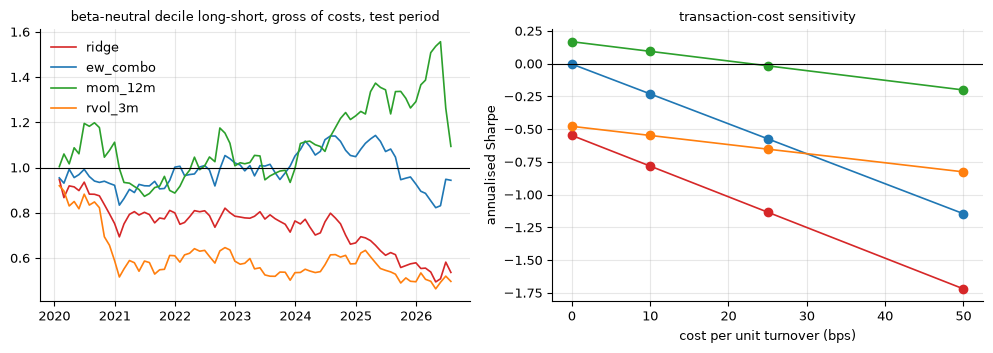

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for c, col in [('ridge', 'C3'), ('ew_combo', 'C0'), ('mom_12m', 'C2'), ('rvol_3m', 'C1')]:
    axes[0].plot((1 + port[c][0]).cumprod(), label=c, color=col, lw=1.2)
    axes[1].plot(COSTS, cost_tab.loc[c], marker='o', label=c, color=col, lw=1.2)
axes[0].axhline(1, color='k', lw=0.8); axes[0].set_title('beta-neutral decile long-short, gross of costs, test period', fontsize=9)
axes[0].legend(frameon=False)
axes[1].axhline(0, color='k', lw=0.8); axes[1].set_xlabel('cost per unit turnover (bps)'); axes[1].set_ylabel('annualised Sharpe')
axes[1].set_title('transaction-cost sensitivity', fontsize=9)
fig.tight_layout()

## 12. Robustness checks

Three checks. First, a walk-forward version of the ridge model: refit each December on all data available to that point (first fit uses 2005-2009), predict the following twelve months, so that predictions cover 2010 to 2026 instead of a single test window. The equal-weight combination signs are recomputed at each refit from the data available at that time. Two things are not point-in-time in this check: the ridge penalty is the one chosen on the 2016-2019 validation period, and the single-signal rows use signs taken from the 2005-2015 training period. The single-signal rows are therefore just the natural-sign IC over 2010-2026 with a fixed sign flip, not a held-out test. Second, the same walk-forward with an unstandardised target, to show the effect of the scaling choice made in section 6. Third, mean beta-adjusted return by score decile, to check whether the IC reflects a monotone relation or is driven by the tails.

In [16]:
def walk_forward(target, alpha, first_year=2010):
    out, coefs, ew = [], {}, []
    for yr in range(first_year, pdates.max().year + 1):
        cut = pd.Timestamp(f'{yr - 1}-12-31')
        fit = (pdates <= cut - pd.DateOffset(months=1)) & target.notna().values   # target for the cut month is not known yet
        pred_mask = (pdates > cut) & (pdates <= pd.Timestamp(f'{yr}-12-31'))
        m = Ridge(alpha=alpha).fit(X[fit], target.values[fit])
        coefs[yr] = m.coef_
        out.append(pd.Series(m.predict(X[pred_mask]), index=panel.index[pred_mask]))
        s = np.sign(IC[1].loc[IC[1].index <= cut - pd.DateOffset(months=1), MODEL_FEATS].mean())
        ew.append((Z.loc[pred_mask, MODEL_FEATS] * s).mean(axis=1))
    return pd.concat(out), pd.DataFrame(coefs, index=MODEL_FEATS).T, pd.concat(ew)

wf_pred, wf_coef, wf_ew = walk_forward(y, best_alpha['ridge'])
wf = pd.concat([wf_pred.rename('ridge_wf'), wf_ew.rename('ew_combo_wf'), PRED[MODEL_FEATS], y.rename('t')], axis=1).dropna(subset=['ridge_wf', 't'])
wf_ic = rank_ic(wf, ['ridge_wf', 'ew_combo_wf'] + MODEL_FEATS, 't')
wf_tab = pd.DataFrame({c: ic_summary(wf_ic[c]) for c in wf_ic.columns}).T
print(f'walk-forward out-of-sample rank IC, {wf_ic.index.min().date()} to {wf_ic.index.max().date()} (single signals signed by full-training-period IC)')
display(wf_tab.round(3))
print('mean IC by calendar year')
wf_ic[['ridge_wf', 'ew_combo_wf', 'rev_1m', 'rvol_3m', 'mom_12m']].groupby(wf_ic.index.year).mean().round(3).T

walk-forward out-of-sample rank IC, 2010-01-29 to 2026-07-31 (single signals signed by full-training-period IC)


,mean_ic,ic_std,icir,t_nw,hit_rate,n_months
ridge_wf,0.013,0.130,0.097,1.440,0.538,199.0
ew_combo_wf,0.010,0.128,0.078,1.155,0.467,199.0
rev_1m,0.013,0.113,0.112,1.695,0.503,199.0
mom_3m,0.004,0.128,0.029,0.414,0.533,199.0
mom_6m,0.008,0.146,0.057,0.856,0.513,199.0
mom_12m,0.002,0.149,0.012,0.179,0.528,199.0
accel,0.002,0.108,0.018,0.265,0.508,199.0
rvol_3m,0.029,0.168,0.175,2.522,0.578,199.0
vol_surp,0.006,0.057,0.100,1.491,0.523,199.0


mean IC by calendar year


date,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ridge_wf,0.017,0.020,0.021,0.021,0.062,0.031,-0.035,0.037,0.013,0.093,-0.054,0.006,-0.002,0.015,-0.012,-0.020,-0.005
ew_combo_wf,0.023,0.042,-0.008,0.010,0.033,-0.026,-0.008,0.009,0.001,0.024,-0.053,0.077,-0.003,0.032,0.004,-0.006,0.022
rev_1m,0.007,0.011,0.026,-0.003,0.031,0.022,0.035,0.022,0.004,0.102,-0.005,0.019,0.020,0.006,-0.044,-0.022,-0.036
rvol_3m,0.012,0.065,0.039,0.022,0.088,0.068,-0.039,0.068,0.017,0.064,-0.084,0.087,-0.040,0.036,0.077,-0.001,0.015
mom_12m,-0.005,0.013,0.052,0.021,-0.009,0.059,-0.060,-0.017,-0.016,0.039,0.013,-0.100,-0.011,0.020,0.052,-0.001,-0.038


walk-forward ridge decile portfolio, 2010-2026:
           0 bps  10 bps  25 bps  50 bps
ann_ret   -0.022  -0.051  -0.093  -0.163
ann_vol    0.126   0.126   0.127   0.128
sharpe    -0.178  -0.401  -0.733  -1.275
max_dd    -0.598  -0.711  -0.833  -0.942
turnover   2.349   2.349   2.349   2.349
total_ret -0.395  -0.622  -0.814  -0.943


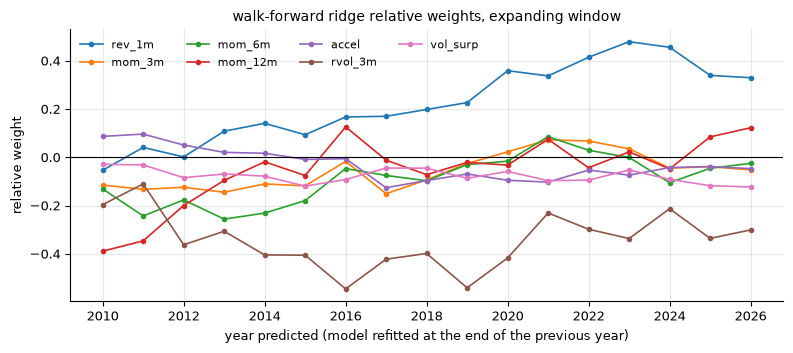

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.6))
wf_w = wf_coef.div(wf_coef.abs().sum(axis=1), axis=0)
for f in MODEL_FEATS:
    ax.plot(wf_w.index, wf_w[f], marker='.', label=f, lw=1.2)
ax.axhline(0, color='k', lw=0.8); ax.set_xlabel('year predicted (model refitted at the end of the previous year)')
ax.set_ylabel('relative weight')
ax.set_title('walk-forward ridge relative weights, expanding window', fontsize=10)
ax.legend(frameon=False, ncol=4, fontsize=8); fig.tight_layout()

pret_wf, to_wf = decile_ls(wf_pred, panel['fwd_1'].reindex(wf_pred.index), panel['beta'].reindex(wf_pred.index))
print('walk-forward ridge decile portfolio, 2010-2026:')
print(pd.DataFrame({f'{b} bps': perf(pret_wf, to_wf, b) for b in COSTS}).round(3).to_string())

In [18]:
# target scaling: demeaned but not standardised target
y_unscaled = winsorize_cs(panel, ['fwdadj_1']).iloc[:, 0]
y_unscaled = y_unscaled - y_unscaled.groupby(level='date').transform('mean')
wf_pred_u, wf_coef_u, _ = walk_forward(y_unscaled, best_alpha['ridge'])
ic_u = rank_ic(pd.concat([wf_pred_u.rename('p'), y.rename('t')], axis=1).dropna(), ['p'], 't')['p']
print('walk-forward ridge, standardised target:  ', ic_summary(wf_ic['ridge_wf']).round(3).to_dict())
print('walk-forward ridge, unstandardised target:', ic_summary(ic_u).round(3).to_dict())
print('relative weights of the first refit (fitted on 2005-2009):')
pd.DataFrame({'standardised': wf_coef.iloc[0] / wf_coef.iloc[0].abs().sum(),
              'unstandardised': wf_coef_u.iloc[0] / wf_coef_u.iloc[0].abs().sum()}).round(3).T

walk-forward ridge, standardised target:   {'mean_ic': 0.013, 'ic_std': 0.13, 'icir': 0.097, 't_nw': 1.44, 'hit_rate': 0.538, 'n_months': 199.0}
walk-forward ridge, unstandardised target: {'mean_ic': -0.004, 'ic_std': 0.131, 'icir': -0.03, 't_nw': -0.47, 'hit_rate': 0.447, 'n_months': 199.0}
relative weights of the first refit (fitted on 2005-2009):


,rev_1m,mom_3m,mom_6m,mom_12m,accel,rvol_3m,vol_surp
standardised,-0.054,-0.115,-0.131,-0.389,0.087,-0.196,-0.029
unstandardised,-0.045,-0.124,-0.240,-0.381,0.109,0.077,0.025


In [19]:
# decile spreads of beta-adjusted forward return, walk-forward period
rows = {}
for c in ['ridge_wf', 'ew_combo_wf', 'rev_1m', 'rvol_3m']:
    d = wf[[c]].join(panel['fwdadj_1']).dropna()
    dec = d.groupby(level='date')[c].rank(pct=True).mul(10).clip(upper=9.999).astype(int) + 1
    rows[c] = d.groupby(dec)['fwdadj_1'].mean() * 100
dec_tab = pd.DataFrame(rows).T
dec_tab.columns.name = 'decile (10 = highest score)'
print('mean beta-adjusted 1-month forward return by score decile, percent per month, 2010-2026')
dec_tab.round(2)

mean beta-adjusted 1-month forward return by score decile, percent per month, 2010-2026


decile (10 = highest score),1,2,3,4,5,6,7,8,9,10
ridge_wf,0.35,-0.02,-0.03,-0.02,-0.05,-0.03,-0.01,-0.01,0.06,-0.03
ew_combo_wf,0.34,-0.02,-0.04,-0.15,0.05,-0.01,0.05,-0.01,-0.06,0.08
rev_1m,-0.01,-0.08,-0.12,-0.06,-0.04,0.12,0.16,0.00,0.12,0.14
rvol_3m,0.40,-0.06,0.01,-0.15,-0.15,-0.10,-0.09,0.06,0.08,0.21


## 13. Results

Sample: 1495 tickers, 298,167 stock-months over 260 month-ends from January 2005 to August 2026 (the last month has no forward return, so 259 months enter the one-month tests). The universe grows from about 770 names per month in 2005 to about 1490 in 2026 because only current index members are observed.

Single signals. Realised volatility is the only signal whose full-sample mean rank IC on the beta-adjusted target is clearly different from zero: -0.028 at one month (Newey-West t = -2.8, 43% of months positive), -0.039 at three months and -0.051 at six, so lower-volatility stocks had higher beta-adjusted returns on average over 2005-2026. Short-term reversal has a mean IC of +0.010 (t = 1.4). Every momentum-type signal (3, 6 and 12 month, acceleration, beta-adjusted 12 month, distance from the 200-day average) sits between -0.014 and +0.011 at all horizons with |t| below 1.3. Volume surprise is small and negative (-0.005, t = -1.6). On raw rather than beta-adjusted returns the volatility IC changes sign to +0.005, so the low-volatility result only appears after removing ex-ante market beta.

Combination. On the validation period (2016-2019), with models fitted on 2005-2015 only, Ridge, Lasso and Elastic Net reach a mean IC of 0.026 to 0.029, below reversal alone at 0.041 (t = 2.5) and roughly level with volatility alone at 0.027; the equal-weight combination scores 0.019. In the train-only fits all three models put most of the absolute weight on volatility (0.58 to 0.78), with smaller positive weights on reversal and 12-month momentum; refitted on train plus validation, Lasso and Elastic Net keep only reversal and volatility. Ridge picks the heaviest penalty in the grid and its validation IC is nearly flat beyond 1e6 (0.0291 to 0.0293), so the direction the data supports is close to a covariance-weighted mix of the signals rather than anything that uses their joint structure. Nothing in the validation period suggests that combining the signals adds information beyond the best single one, and that single signal was identified on the same period.

On the test period (2020-2026, 79 months) nothing is distinguishable from zero. The models score 0.003 to 0.005 (t below 0.3), the equal-weight combination 0.012 (t = 0.8), and no single signal has |t| above 0.9. Reversal has the opposite sign to the training period (-0.007) and volatility keeps its training sign but weakly (0.013, t = 0.6). The walk-forward version, refitted every year over 2010-2026, gives a mean IC of 0.013 for Ridge (t = 1.4, 54% positive months), compared with 0.029 for volatility alone over the same months (t = 2.5). With the caveats in section 12 (penalty chosen on 2016-2019, single-signal signs from 2005-2015), the combined model is not better than its best component. With an unstandardised target the walk-forward Ridge IC is -0.004; the first refit differs from the standardised one mainly in the sign of the volatility weight (+0.08 against -0.20), consistent with high-dispersion months carrying more weight in the pooled fit, although that mechanism is not isolated here.

Portfolio. The beta-neutral decile long-short on the Ridge score loses 8.3% a year over the test period gross of costs (Sharpe -0.55, maximum drawdown 48%) with turnover of about 3.0 per month, i.e. roughly three quarters of the book replaced at each rebalance. The equal-weight combination is flat (Sharpe 0.00). Twelve-month momentum (0.17) and volume surprise (0.22) have positive gross Sharpe ratios; only momentum, with turnover of 1.2, stays positive at 10 bps per unit of turnover (0.09), and at 25 bps every portfolio is negative. Over 2010-2026 the walk-forward Ridge portfolio has a gross Sharpe of -0.18. The decile table shows that the small positive rank IC does not come with a positive top-minus-bottom spread: the lowest-score decile (dominated by high-volatility names, since volatility carries the largest weight in every refit) has the highest pooled beta-adjusted return at +0.35% a month and deciles 2 to 10 are within -0.05% to +0.06%. That extreme decile is where survivorship bias would be expected to show up, since it contains volatile names that fell and are still listed, but the experiment cannot separate that from a genuine effect.

Overall: in this liquid US universe and period, simple price and volume characteristics carry little information about next-month beta-adjusted returns. Low volatility is the most consistent effect, with a mean IC around 0.03 over the full sample and over 2010-2026, but it is weak and insignificant in 2020-2026 (0.013, t = 0.6) and negative in three of the last seven calendar years. Short-term reversal had a positive IC in 2016-2019 and a negative one in 2020-2026. No momentum variant is detectable; the survivor-based universe is one plausible reason, but its contribution is not measured. Regularised linear combinations did not beat the best single signal on either the validation or the test period, and at 25 bps per unit of turnover none of the monthly decile portfolios has a positive Sharpe ratio.

## 14. Limitations

- Survivorship. The ticker list is the S&P 1500 as of September 2026. Companies acquired, bankrupt or dropped from all three indices before then are absent and there are no delisting returns. Using the 1500 keeps demoted names but not delisted ones. The bias is expected to inflate the forward returns of stocks that fell hard and survived, which would flatter reversal and high volatility and penalise momentum; the size of the effect cannot be measured with this data, so the momentum results in particular should not be over-interpreted.
- Data quality. Yahoo Finance history contains adjustment errors and spliced securities. 54 daily observations were zeroed by two mechanical rules; smaller errors below the thresholds remain, and volume is only split adjusted.
- No fundamentals, market capitalisation or point-in-time sector classification, so the universe is defined by liquidity alone and nothing is sector neutral. Realised volatility and short-term reversal both have large industry components, and part of what is measured here may be industry rotation.
- Beta comes from 252 daily returns and is noisy; the beta-adjusted target and the beta-neutral portfolio inherit that noise. Betas were clipped to the range 0 to 3.
- The backtest trades at month-end closes, ignores intra-month weight drift, charges a flat rate per unit of turnover and ignores borrow costs, short availability and market impact. With turnover of 2.5 to 3.5 per month the cost assumption decides the conclusion for any fast signal.
- One 21-year sample and one test window that opens with the 2020 crash. The walk-forward check reduces dependence on the split, but the sample is still a single realisation of a period in which several of these effects are known to have weakened.
- Some selection was done on validation data (the penalty grids, the choice of horizons) and single-signal signs were taken from the training period. The correlation threshold for dropping signals used full-sample signal correlations, which involve no return data. The walk-forward check reuses the validation-chosen penalty for all years, including 2010-2015. The test period was used once.